# Variational Autoencoder with PyTorch 

In [28]:
pip install torch torchvision

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: C:\Users\BOUKA\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## Imports 

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in 

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory
import os
for dirname, _, filenames in os.walk('/inputs'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import nn, optim
from torch.autograd import Variable
from sklearn.decomposition import PCA

import pandas as pd
import numpy as np
from sklearn import preprocessing

# Any results you write to the current directory are saved as output.

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

## Get a quick view of the data 

In [4]:
DATA_PATH = r'C:\Users\BOUKA\Downloads\VAE-Code\inputs\heart_cleveland_upload.csv'
df = pd.read_csv(DATA_PATH, sep=',')
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'condition'],
      dtype='object')

## Process datasets

### Heart Cleveland dataset

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        297 non-null    int64  
 1   sex        297 non-null    int64  
 2   cp         297 non-null    int64  
 3   trestbps   297 non-null    int64  
 4   chol       297 non-null    int64  
 5   fbs        297 non-null    int64  
 6   restecg    297 non-null    int64  
 7   thalach    297 non-null    int64  
 8   exang      297 non-null    int64  
 9   oldpeak    297 non-null    float64
 10  slope      297 non-null    int64  
 11  ca         297 non-null    int64  
 12  thal       297 non-null    int64  
 13  condition  297 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 32.6 KB


In [9]:
df['condition'].value_counts()

condition
0    160
1    137
Name: count, dtype: int64

#### Null Values

<Axes: >

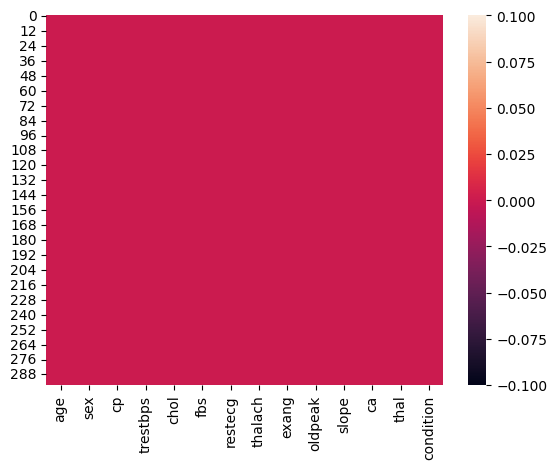

In [10]:
sns.heatmap(df.isnull())

In [36]:
df.isnull().sum()

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalach      0
exang        0
oldpeak      0
slope        0
ca           0
thal         0
condition    0
dtype: int64

In [37]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,2.158249,131.693603,247.350168,0.144781,0.996633,149.599327,0.326599,1.055556,0.602694,0.676768,0.835017,0.461279
std,9.049736,0.468500,0.964859,17.762806,51.997583,0.352474,0.994914,22.941562,0.469761,1.166123,0.618187,0.938965,0.956690,0.499340
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,2.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,56.000000,1.000000,2.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,0.000000,0.000000
75%,61.000000,1.000000,3.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,1.000000,1.000000,2.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.000000,2.000000,1.000000


#### Cleansing the data: removing outliers

In [38]:
for col in df.columns:
    print(f" {col}  unique val {df[col].unique()} and  counts: {df[col].value_counts()}")

 age  unique val [69 66 65 64 63 61 60 59 58 56 52 51 45 42 40 38 34 74 71 70 62 57 55 54
 50 49 48 46 44 41 35 29 76 68 67 53 47 43 39 37 77] and  counts: age
58    18
57    17
54    16
59    14
60    12
51    12
56    11
52    11
44    11
62    11
64    10
41    10
63     9
67     9
61     8
55     8
45     8
42     8
65     8
46     7
48     7
50     7
43     7
66     7
53     7
49     5
47     5
70     4
68     4
39     4
35     4
69     3
71     3
40     3
34     2
37     2
76     1
29     1
74     1
38     1
77     1
Name: count, dtype: int64
 sex  unique val [1 0] and  counts: sex
1    201
0     96
Name: count, dtype: int64
 cp  unique val [0 1 2 3] and  counts: cp
3    142
2     83
1     49
0     23
Name: count, dtype: int64
 trestbps  unique val [160 140 150 138 110 170 145 134 178 120 118 152 125 148 156 128 136 130
 124 154 135 132 108 192 101 105 112 126 122 180 115 146 155 102 172 100
  94 129 142 144 106 117 158 174 164 114 165 200 123 104] and  counts: trestbps
120    37

* **There are two classes: 0 is 'Non Diseased' and 1 is 'Diseased'**

### Visualizations

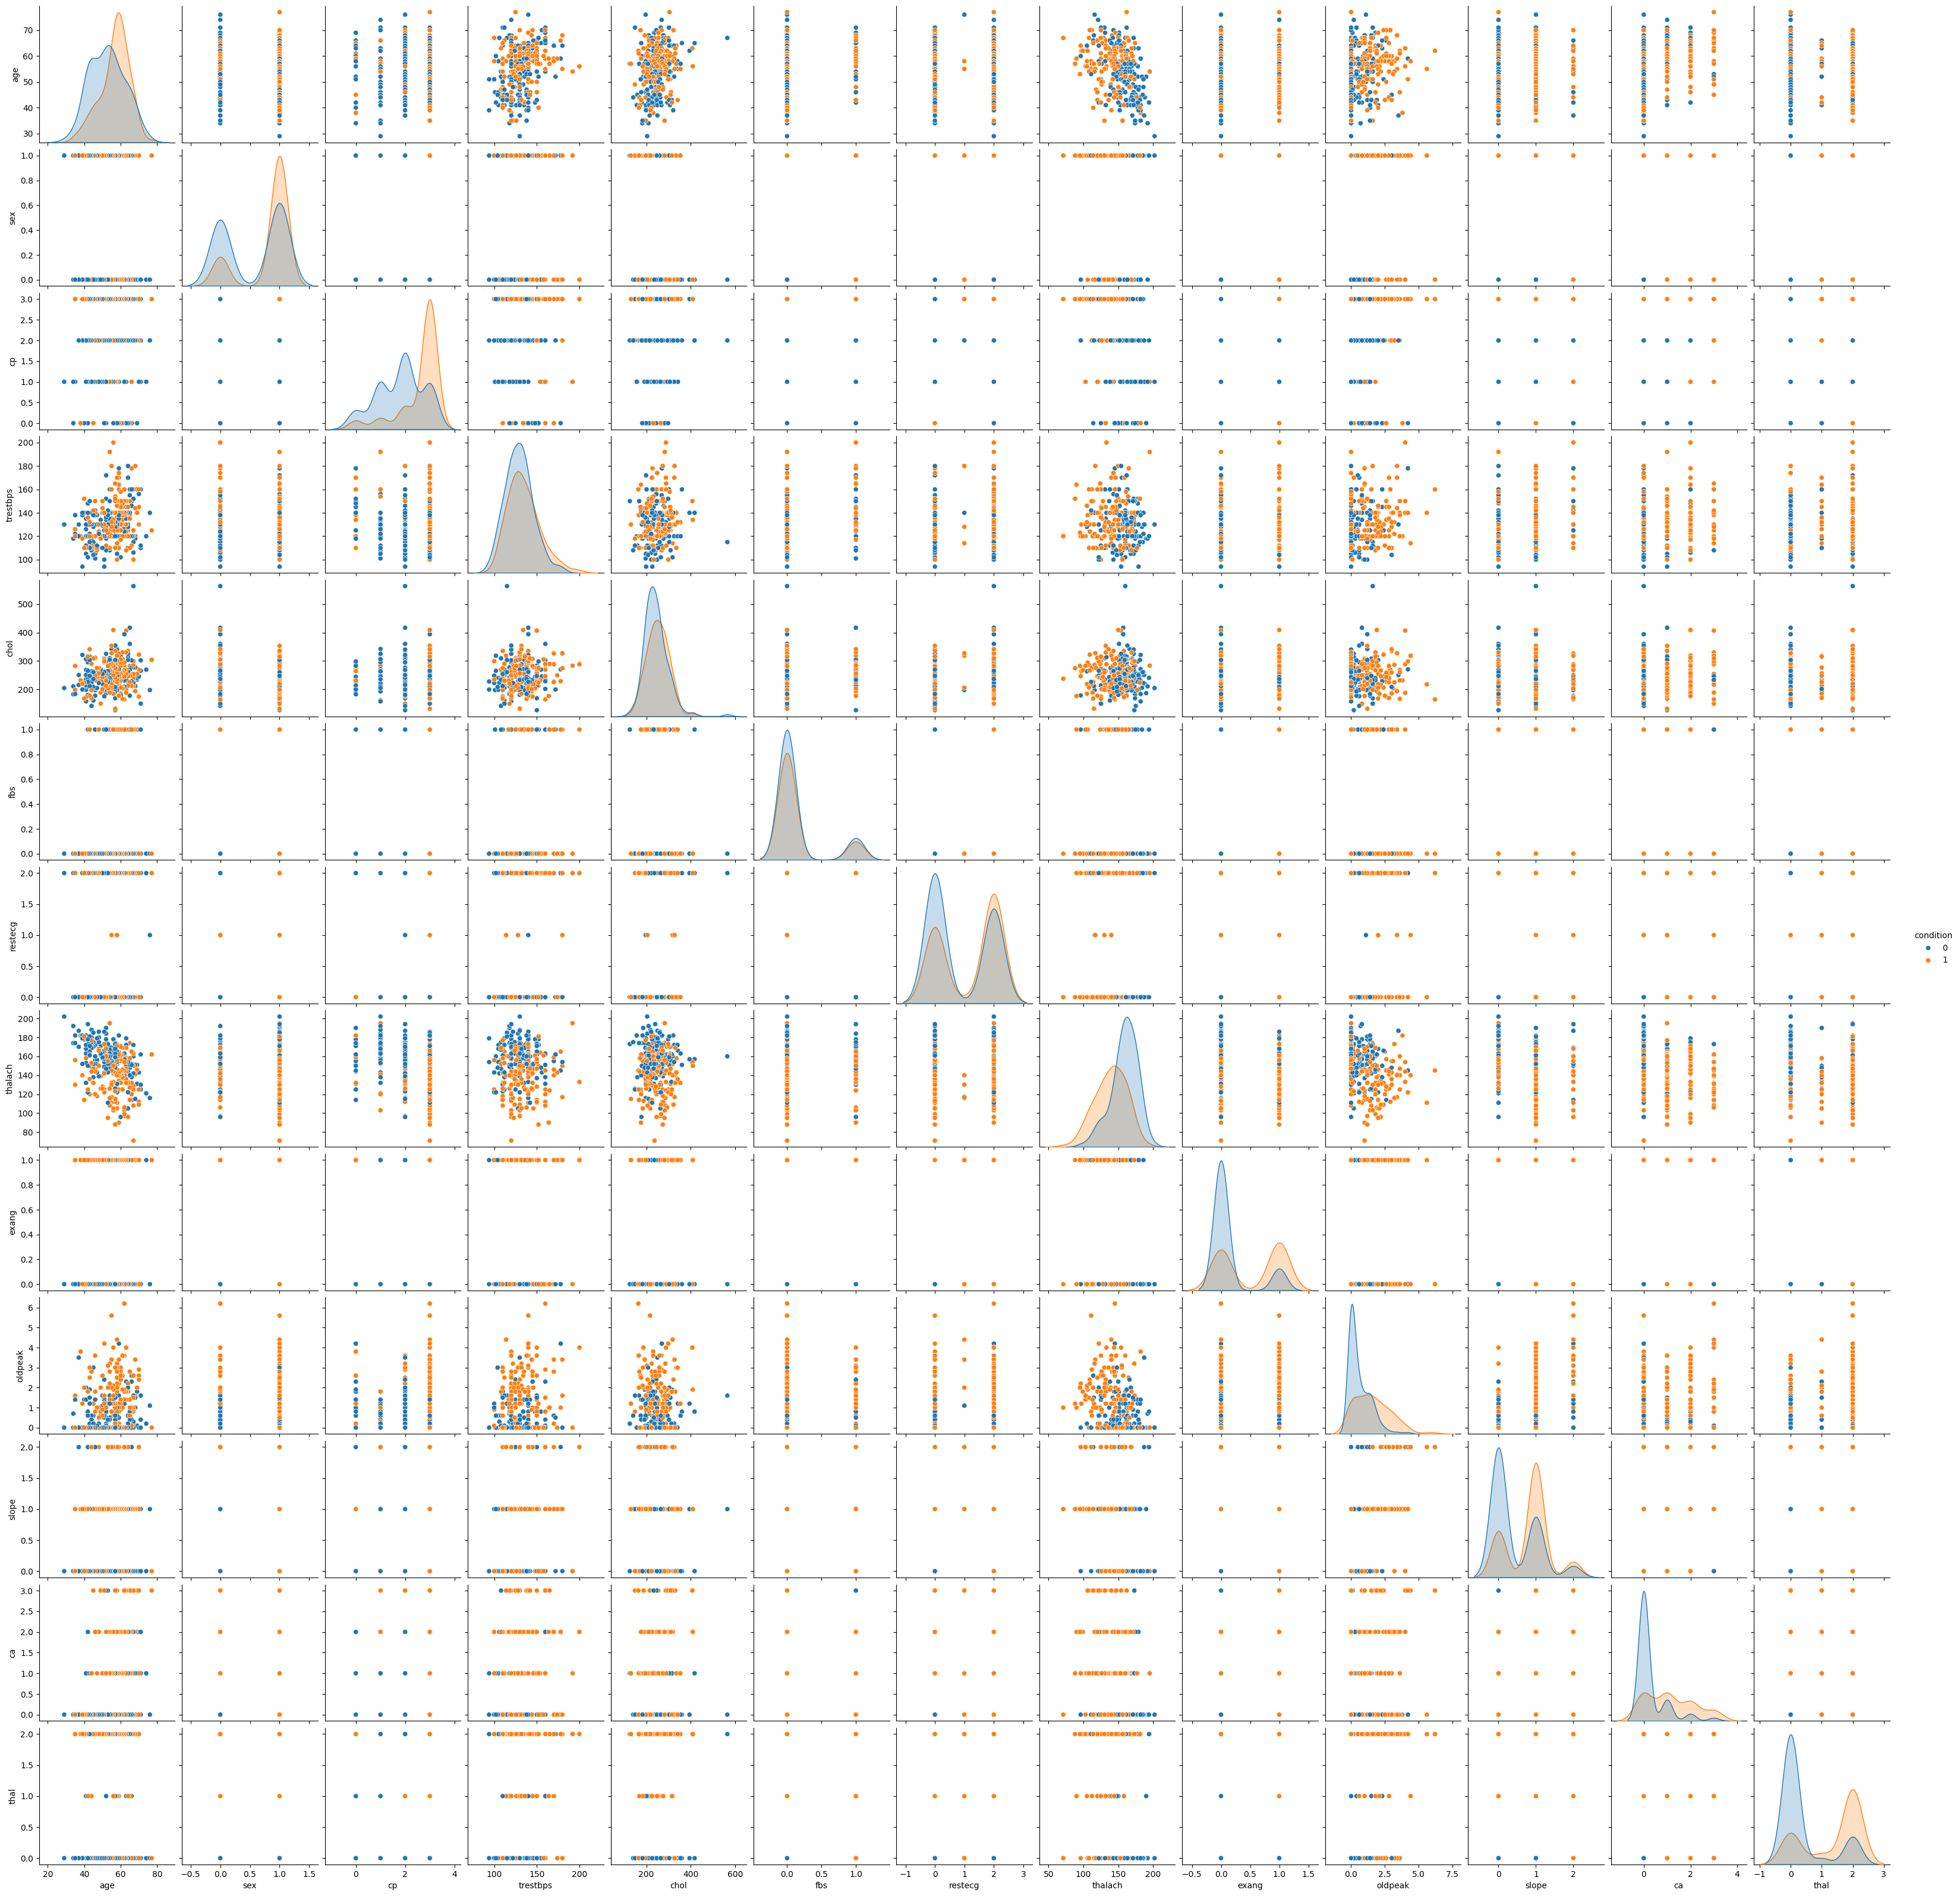

In [39]:
sns.pairplot(data=df, hue='condition')

#### Spearman Rank Correlation

<Axes: >

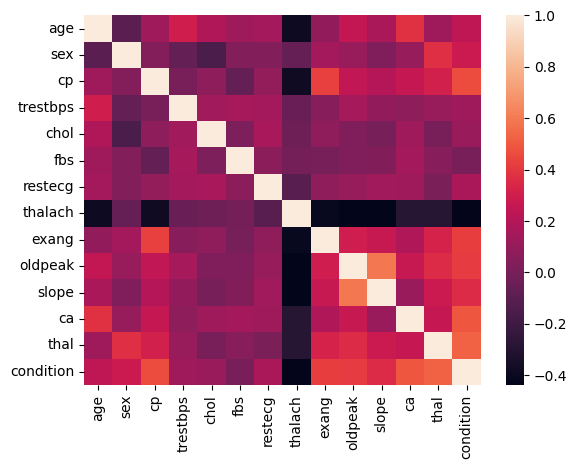

In [40]:
corr = df.corr(method="spearman")
sns.heatmap(corr,annot=False)

* We drop outlier values using **IQR(Interquartile Range Method)**

In [41]:
df.rename(columns={'condition':"Outcome"}, inplace=True)

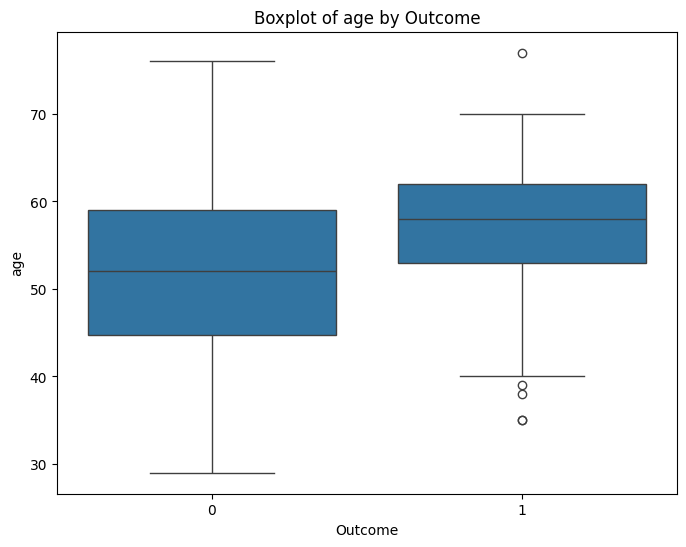

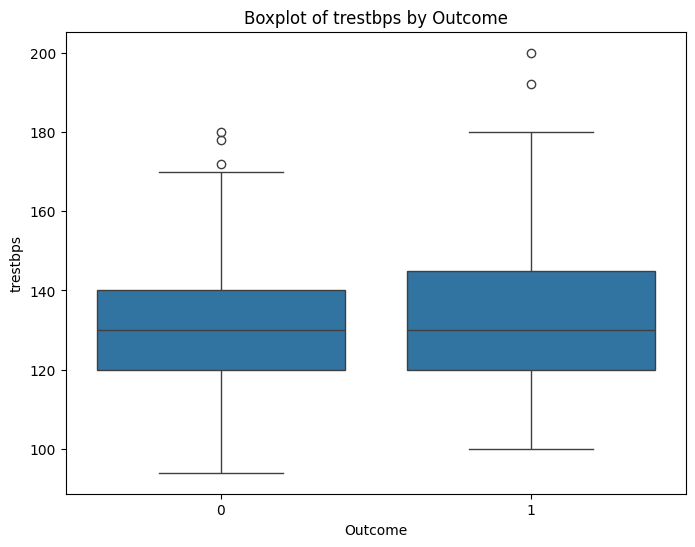

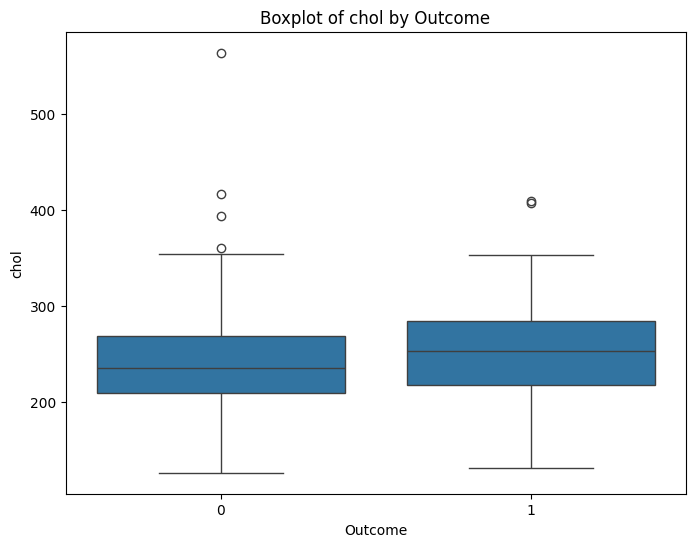

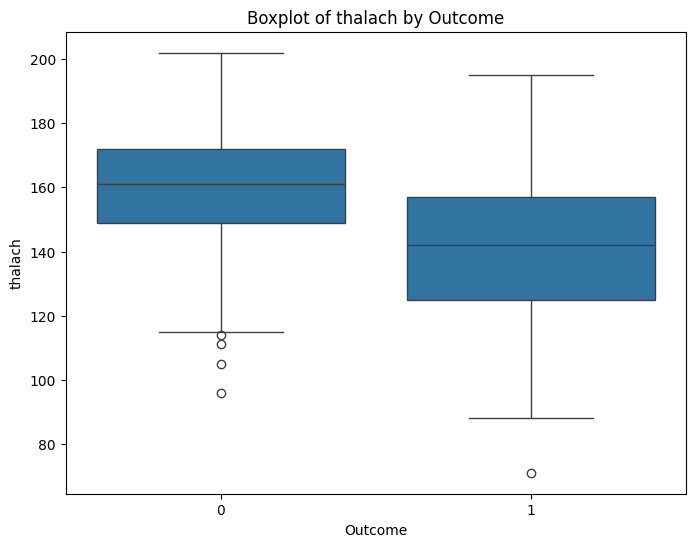

In [42]:
cols = [col for col in df.columns if col!="Outcome"]
cont_cols = ["age", 'trestbps', "chol", "thalach"]
for col in cont_cols:
        plt.figure(figsize=(8, 6))
        sns.boxplot(data=df, x="Outcome", y=col)
        plt.title(f'Boxplot of {col} by Outcome')
        plt.show()

In [43]:
def removeOutlier(col):
    sorted(col)
    quant1, quant2 = col.quantile([0.25, 0.75])
    IQR = quant2 - quant1
    lowerRange = quant1 - (1.5 * IQR)
    upperRange = quant2 + (1.5 * IQR)
    return lowerRange, upperRange

In [44]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,Outcome
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,2.158249,131.693603,247.350168,0.144781,0.996633,149.599327,0.326599,1.055556,0.602694,0.676768,0.835017,0.461279
std,9.049736,0.468500,0.964859,17.762806,51.997583,0.352474,0.994914,22.941562,0.469761,1.166123,0.618187,0.938965,0.956690,0.499340
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,2.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,56.000000,1.000000,2.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,0.000000,0.000000
75%,61.000000,1.000000,3.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,1.000000,1.000000,2.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.000000,2.000000,1.000000


In [45]:
cont_cols = ["age", 'trestbps', "chol", "thalach"]

In [47]:
for col in cont_cols:
    lowScore, highScore = removeOutlier(df[col])
    print(f"Column: {col}, Lower Bound: {lowScore}, Upper Bound: {highScore}")
    df[col] = np.where(df[col]>highScore, highScore, df[col])
    df[col] = np.where(df[col]<lowScore, lowScore, df[col])

Column: age, Lower Bound: 28.5, Upper Bound: 80.5
Column: trestbps, Lower Bound: 90.0, Upper Bound: 170.0
Column: chol, Lower Bound: 113.5, Upper Bound: 373.5
Column: thalach, Lower Bound: 83.5, Upper Bound: 215.5


In [48]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,Outcome
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,2.158249,131.343434,246.260943,0.144781,0.996633,149.641414,0.326599,1.055556,0.602694,0.676768,0.835017,0.461279
std,9.049736,0.468500,0.964859,16.801401,47.836752,0.352474,0.994914,22.807957,0.469761,1.166123,0.618187,0.938965,0.956690,0.499340
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,83.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,2.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,56.000000,1.000000,2.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,0.000000,0.000000
75%,61.000000,1.000000,3.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,1.000000,1.000000,2.000000,1.000000
max,77.000000,1.000000,3.000000,170.000000,373.500000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.000000,2.000000,1.000000


* **Check if the outliers are handled**

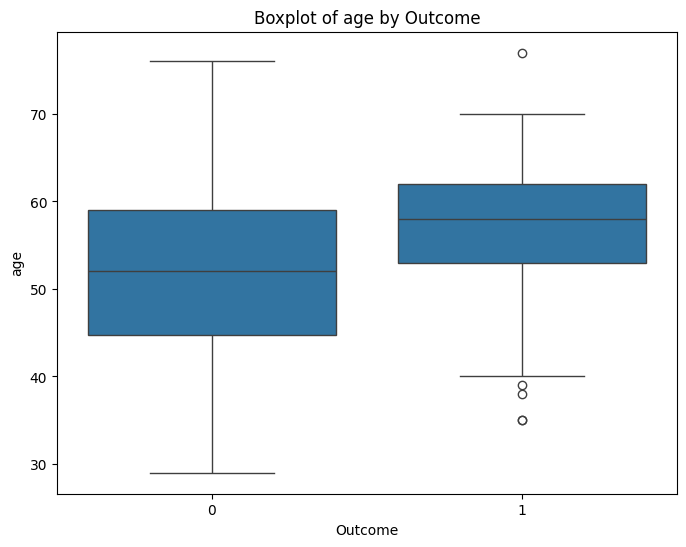

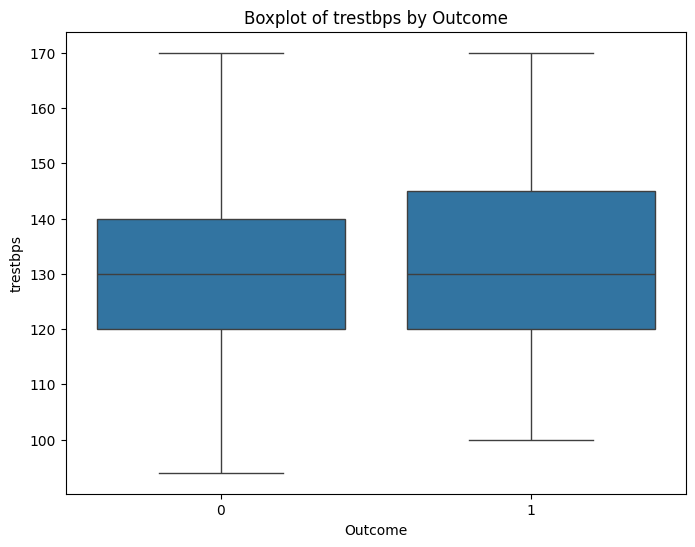

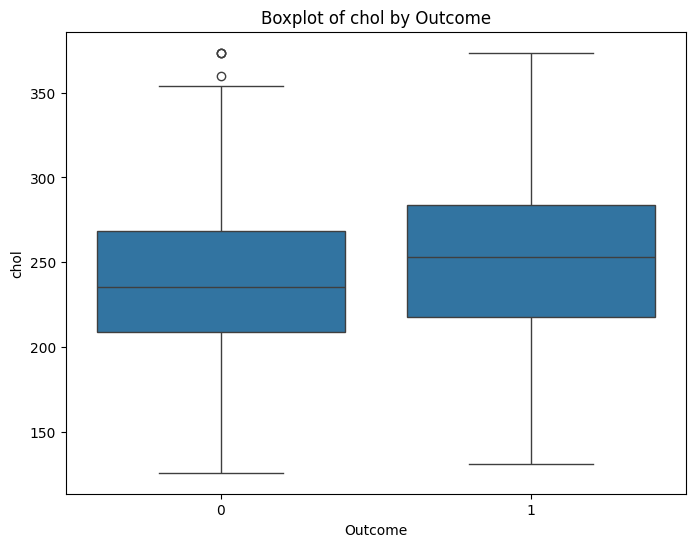

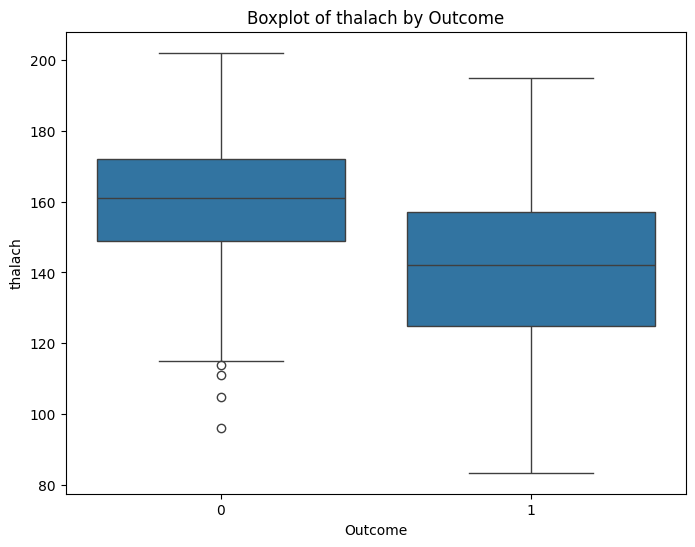

In [49]:
cols = [col for col in df.columns if col!="Outcome"]
for col in cont_cols:
        plt.figure(figsize=(8, 6))
        sns.boxplot(data=df, x="Outcome", y=col)
        plt.title(f'Boxplot of {col} by Outcome')
        plt.show()

### save the preprocessed dataset "HeartCleveland_processed.csv"

In [50]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,Outcome
0,69.0,1,0,160.0,234.0,1,2,131.0,0,0.1,1,1,0,0
1,69.0,0,0,140.0,239.0,0,0,151.0,0,1.8,0,2,0,0
2,66.0,0,0,150.0,226.0,0,0,114.0,0,2.6,2,0,0,0
3,65.0,1,0,138.0,282.0,1,2,174.0,0,1.4,1,1,0,1
4,64.0,1,0,110.0,211.0,0,2,144.0,1,1.8,1,0,0,0


In [51]:
df.to_csv(path_or_buf="HeartCleveland_processed.csv")